Accuracy: 0.8333333333333334

Confusion Matrix:
 [[13  0  1]
 [ 0 11  3]
 [ 0  2  6]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.85      0.79      0.81        14
           2       0.60      0.75      0.67         8

    accuracy                           0.83        36
   macro avg       0.82      0.82      0.81        36
weighted avg       0.85      0.83      0.84        36



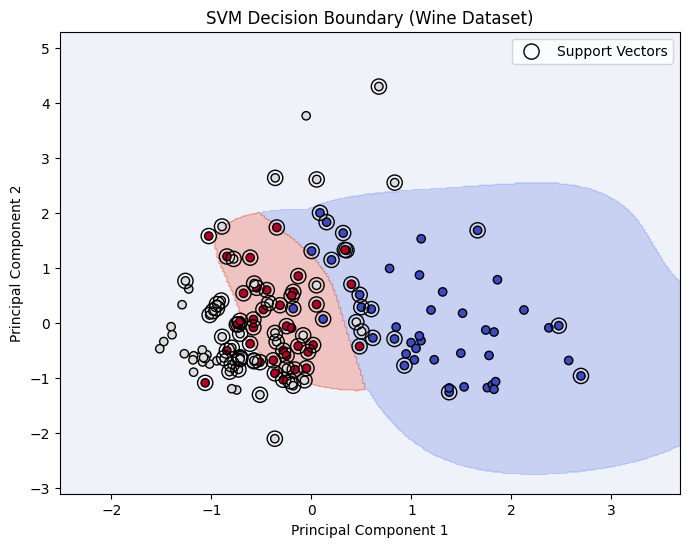

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
wine = datasets.load_wine()
X = wine.data
y = wine.target

# Reduce to 2 dimensions using PCA
pca = PCA(n_components=2)
X = pca.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train SVM model
model = SVC(kernel='rbf', C=1.0)
model.fit(X_train, y_train)

# -----------------------
# Model Evaluation
# -----------------------

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# -----------------------
# Visualization
# -----------------------

# Create mesh grid for decision boundary
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# Predict for each grid point
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision regions
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

# Plot training points
plt.scatter(
    X_train[:,0], X_train[:,1],
    c=y_train,
    cmap=plt.cm.coolwarm,
    edgecolors='k'
)

# Highlight support vectors
plt.scatter(
    model.support_vectors_[:,0],
    model.support_vectors_[:,1],
    s=120,
    facecolors='none',
    edgecolors='black',
    label="Support Vectors"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("SVM Decision Boundary (Wine Dataset)")
plt.legend()
plt.show()